# 🌱 Verra VCS Energy Registry — Exploratory Data Analysis
### Uncovering Data Anomalies & the "Zombie Registry" Phenomenon

**Author:** Andita Rachmania  
**Dataset:** Verra VCS Registry — Energy Industries (All Projects, Registered, Pipeline, Inactive)  
**Source:** [registry.verra.org](https://registry.verra.org/app/search/VCS)  
**Focus:** Data quality auditing, anomaly detection, and carbon market integrity analysis

---

> *This notebook investigates structural data patterns in the Verra Verified Carbon Standard (VCS) registry
> for energy industry projects. The analysis surfaces two main stories: a "Zombie Registry" of 597 projects
> stalled in verification limbo, and a suite of data anomalies that raise questions about carbon credit
> market integrity.*

---
## Table of Contents
1. [Setup & Data Loading](#1)
2. [Dataset Overview](#2)
3. [Data Quality Audit](#3)
4. [🧟 The Zombie Registry — Late to Verify Deep Dive](#4)
5. [🔍 Anomaly Findings](#5)
6. [Key Insights & Implications](#6)


## 1. Setup & Data Loading <a id='1'></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import date
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2d3348',
    'axes.labelcolor':  '#e2e8f0',
    'xtick.color':      '#94a3b8',
    'ytick.color':      '#94a3b8',
    'text.color':       '#e2e8f0',
    'grid.color':       '#2d3348',
    'grid.linewidth':   0.6,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.titlepad':    10,
})

GREEN  = '#10b981'
YELLOW = '#f59e0b'
RED    = '#ef4444'
BLUE   = '#3b82f6'
PURPLE = '#8b5cf6'
MUTED  = '#94a3b8'

print('Libraries loaded ✓')

Libraries loaded ✓


### 1.1 Load the four CSV files

Files: `allprojects.csv`, `registered.csv`, `pipeline.csv`, and `inactive.csv`.

In [4]:
# ── Update this path if your CSVs are in a different folder ──────────────────
DATA_PATH = '.'   # '.' = same folder as this notebook

all_df   = pd.read_csv(f'{DATA_PATH}/allprojects.csv')
reg_df   = pd.read_csv(f'{DATA_PATH}/registered.csv')
pipe_df  = pd.read_csv(f'{DATA_PATH}/pipeline.csv')
inact_df = pd.read_csv(f'{DATA_PATH}/inactive.csv')

print(f'All Projects : {all_df.shape[0]:,} rows × {all_df.shape[1]} columns')
print(f'Registered   : {reg_df.shape[0]:,} rows × {reg_df.shape[1]} columns')
print(f'Pipeline     : {pipe_df.shape[0]:,} rows × {pipe_df.shape[1]} columns')
print(f'Inactive     : {inact_df.shape[0]:,} rows × {inact_df.shape[1]} columns')

All Projects : 1,700 rows × 13 columns
Registered   : 1,387 rows × 13 columns
Pipeline     : 176 rows × 13 columns
Inactive     : 102 rows × 13 columns


In [5]:
# ── Clean & enrich ───────────────────────────────────────────────────────────
df = all_df.copy()

# Parse dates
for col in ['Project Registration Date', 'Crediting Period Start Date', 'Crediting Period End Date']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Clean emissions (remove commas → numeric)
df['Emissions'] = pd.to_numeric(
    df['Estimated Annual Emission Reductions'].astype(str).str.replace(',', ''), errors='coerce'
)

# Crediting period duration
df['CP_Duration_Yrs'] = (
    (df['Crediting Period End Date'] - df['Crediting Period Start Date']).dt.days / 365.25
)

# Registration year
df['Reg_Year'] = df['Project Registration Date'].dt.year

# Source dataset tag
reg_ids  = set(reg_df['ID'])
pipe_ids = set(pipe_df['ID'])
inact_ids = set(inact_df['ID'])
df['Source'] = df['ID'].apply(
    lambda x: 'Registered' if x in reg_ids else 'Pipeline' if x in pipe_ids
              else 'Inactive' if x in inact_ids else 'Other'
)

today = pd.Timestamp(date.today())
print('Data cleaned ✓')
print(f'Date range: {df["Project Registration Date"].min().date()} → {df["Project Registration Date"].max().date()}')

Data cleaned ✓
Date range: 2009-03-17 → 2026-03-25


---
## 2. Dataset Overview <a id='2'></a>

In [6]:
df.head(3)

,ID,Name,Proponent,Project Type,AFOLU Activities,Methodology,Status,Country/Area,Estimated Annual Emission Reductions,Region,Project Registration Date,Crediting Period Start Date,Crediting Period End Date,Emissions,CP_Duration_Yrs,Reg_Year,Source
0,5871,"Biogas Plant at Gujjar Colony, Lahore",Punjab Power Development Company Limited (PPDCL),Energy industries (renewable/non-renewable sou...,NaN,AMS-I.C.; AMS-III.D.,Under validation,Pakistan,"39,186",Asia,NaT,2026-01-01,2035-12-31,39186,9.995893,NaN,Pipeline
1,5860,Ningxia Junfeng Siguquan Coal Mine Well No.2 C...,"Ningxia Junfeng New Energy Technology Co., Ltd.",Energy industries (renewable/non-renewable sou...,NaN,ACM0008,Under validation,China,"111,399",Asia,NaT,2024-10-08,2034-10-07,111399,9.995893,NaN,Pipeline
2,5851,10.2MW Nam Yeim Hydro Power Project,SINGAPORE TREASURE CARBON TECH PTE. LTD.,Energy industries (renewable/non-renewable sou...,NaN,AMS-I.D.,Under development,Lao,"22,841",NaN,NaT,2026-03-01,2036-02-29,22841,9.998631,NaN,Pipeline


In [7]:
print('=== COLUMNS & DATA TYPES ===')
print(df.dtypes.to_string())

=== COLUMNS & DATA TYPES ===
ID                                               int64
Name                                            object
Proponent                                       object
Project Type                                    object
AFOLU Activities                               float64
Methodology                                     object
Status                                          object
Country/Area                                    object
Estimated Annual Emission Reductions            object
Region                                          object
Project Registration Date               datetime64[ns]
Crediting Period Start Date             datetime64[ns]
Crediting Period End Date               datetime64[ns]
Emissions                                        int64
CP_Duration_Yrs                                float64
Reg_Year                                       float64
Source                                          object


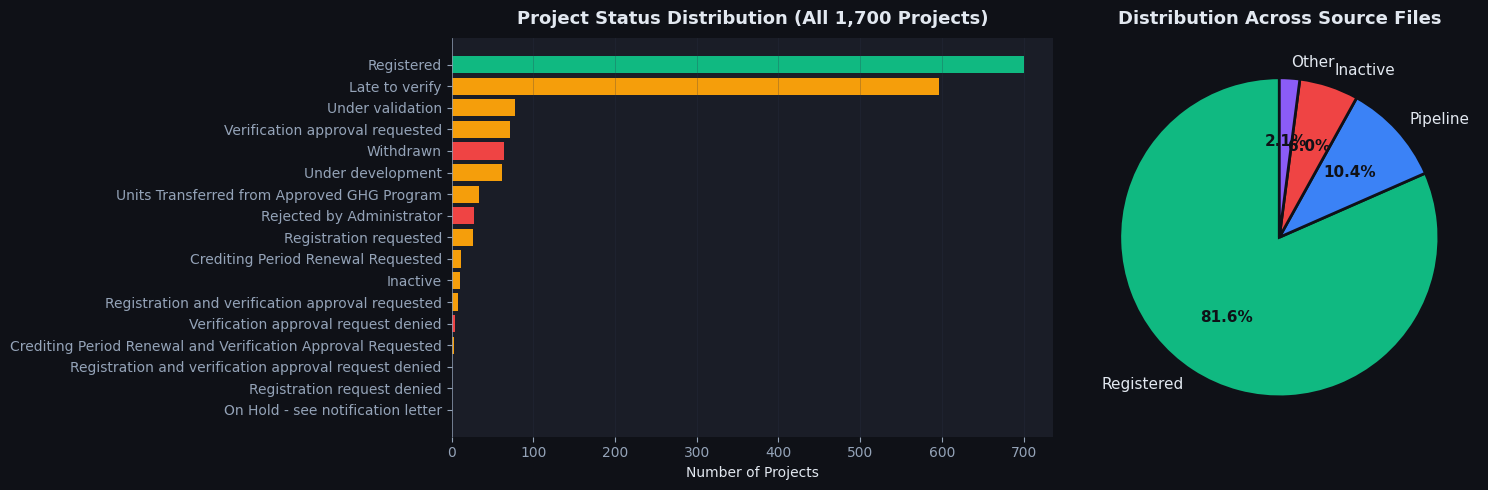

In [8]:
# ── Status distribution ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')

# Bar chart — all statuses
status_counts = df['Status'].value_counts()
colors = [GREEN if 'Registered' in s else RED if any(x in s for x in ['Withdrawn','Rejected','denied'])
          else YELLOW for s in status_counts.index]

axes[0].barh(status_counts.index[::-1], status_counts.values[::-1], color=colors[::-1], edgecolor='none')
axes[0].set_title('Project Status Distribution (All 1,700 Projects)')
axes[0].set_xlabel('Number of Projects')
axes[0].axvline(0, color=MUTED, linewidth=0.5)
for spine in axes[0].spines.values(): spine.set_visible(False)
axes[0].grid(axis='x', alpha=0.3)

# Donut — source dataset
source_counts = df['Source'].value_counts()
wedge_colors = [GREEN, BLUE, RED, PURPLE]
wedges, texts, autotexts = axes[1].pie(
    source_counts.values, labels=source_counts.index,
    colors=wedge_colors[:len(source_counts)],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': '#0f1117', 'linewidth': 2},
    textprops={'color': '#e2e8f0', 'fontsize': 11}
)
for at in autotexts: at.set_color('#0f1117'); at.set_fontweight('bold')
axes[1].set_title('Distribution Across Source Files')

plt.tight_layout()
plt.show()

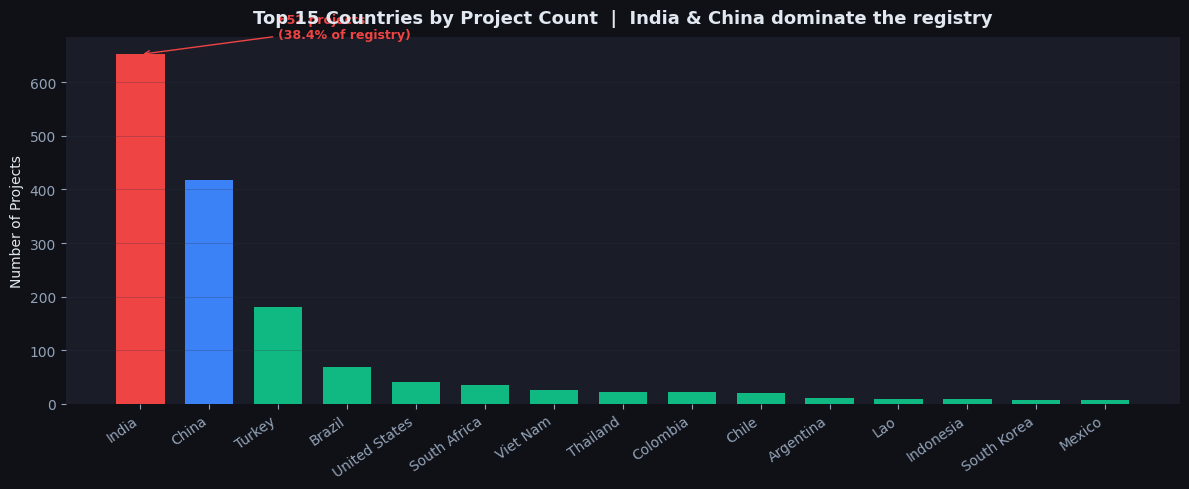

In [9]:
# ── Top countries ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0f1117')

top_countries = df['Country/Area'].value_counts().head(15)
bar_colors = [RED if c == 'India' else BLUE if c == 'China' else GREEN for c in top_countries.index]
bars = ax.bar(top_countries.index, top_countries.values, color=bar_colors, edgecolor='none', width=0.7)

ax.set_title('Top 15 Countries by Project Count  |  India & China dominate the registry')
ax.set_ylabel('Number of Projects')
ax.set_xticklabels(top_countries.index, rotation=35, ha='right')
for spine in ax.spines.values(): spine.set_visible(False)
ax.grid(axis='y', alpha=0.3)

# Annotate India share
india_n = top_countries['India']
ax.annotate(f'{india_n} projects\n({india_n/len(df)*100:.1f}% of registry)',
            xy=('India', india_n), xytext=(2, india_n + 30),
            color=RED, fontsize=9, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=RED))

plt.tight_layout()
plt.show()

---
## 3. Data Quality Audit <a id='3'></a>

Before diving into anomalies, we baseline the overall data completeness. The dataset has 13 fields.  
`AFOLU Activities` is 100% null by design — these are energy projects, not land-use projects, so we exclude it.

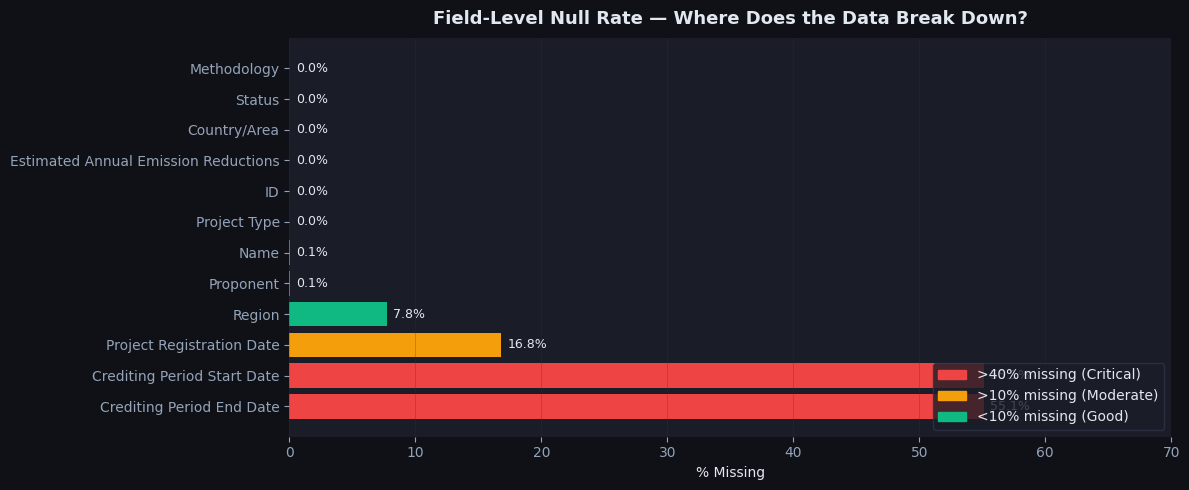

                               Field    Null %
           Crediting Period End Date 55.117647
         Crediting Period Start Date 55.117647
           Project Registration Date 16.823529
                              Region  7.764706
                           Proponent  0.058824
                                Name  0.058824
                        Project Type  0.000000
                                  ID  0.000000
Estimated Annual Emission Reductions  0.000000
                        Country/Area  0.000000
                              Status  0.000000
                         Methodology  0.000000


In [10]:
# ── Null heatmap ─────────────────────────────────────────────────────────────
exclude = ['AFOLU Activities']
check_cols = [c for c in df.columns if c not in exclude + ['Emissions','CP_Duration_Yrs','Reg_Year','Source']]

null_pct = pd.DataFrame({
    'Field': check_cols,
    'Null %': [df[c].isna().mean() * 100 for c in check_cols],
    'Complete %': [df[c].notna().mean() * 100 for c in check_cols],
})
null_pct = null_pct.sort_values('Null %', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0f1117')

bar_colors = [RED if p > 40 else YELLOW if p > 10 else GREEN for p in null_pct['Null %']]
bars = ax.barh(null_pct['Field'], null_pct['Null %'], color=bar_colors, edgecolor='none')

for bar, pct in zip(bars, null_pct['Null %']):
    ax.text(pct + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9, color='#e2e8f0')

ax.set_title('Field-Level Null Rate — Where Does the Data Break Down?')
ax.set_xlabel('% Missing')
ax.set_xlim(0, 70)
for spine in ax.spines.values(): spine.set_visible(False)
ax.grid(axis='x', alpha=0.3)

patches = [mpatches.Patch(color=RED, label='>40% missing (Critical)'),
           mpatches.Patch(color=YELLOW, label='>10% missing (Moderate)'),
           mpatches.Patch(color=GREEN, label='<10% missing (Good)')]
ax.legend(handles=patches, loc='lower right', facecolor='#1a1d27', edgecolor='#2d3348')

plt.tight_layout()
plt.show()

print(null_pct[['Field','Null %']].to_string(index=False))

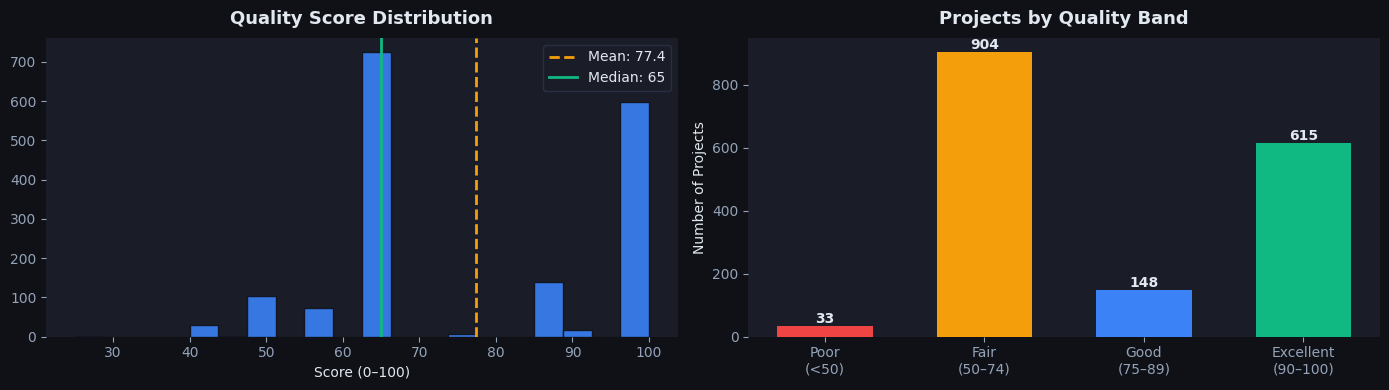

In [11]:
# ── Quality scoring ──────────────────────────────────────────────────────────
WEIGHTS = {
    'Name': 5, 'Proponent': 5, 'Methodology': 20,
    'Project Registration Date': 15, 'Crediting Period Start Date': 15,
    'Crediting Period End Date': 15, 'Region': 10, 'Emissions': 10,
}

def quality_score(row):
    score = 0
    if not pd.isna(row['Name']):                              score += WEIGHTS['Name']
    if not pd.isna(row['Proponent']):                         score += WEIGHTS['Proponent']
    if str(row['Methodology']).strip():                        score += WEIGHTS['Methodology']
    if not pd.isna(row['Project Registration Date']):         score += WEIGHTS['Project Registration Date']
    if not pd.isna(row['Crediting Period Start Date']):       score += WEIGHTS['Crediting Period Start Date']
    if not pd.isna(row['Crediting Period End Date']):         score += WEIGHTS['Crediting Period End Date']
    if not pd.isna(row['Region']):                            score += WEIGHTS['Region']
    if not pd.isna(row['Emissions']) and row['Emissions'] > 0: score += WEIGHTS['Emissions']
    # Bonus: valid date order
    if (not pd.isna(row['Crediting Period Start Date']) and
        not pd.isna(row['Crediting Period End Date']) and
        row['Crediting Period End Date'] > row['Crediting Period Start Date']):
        score += 5
    return min(score, 100)

df['Quality_Score'] = df.apply(quality_score, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.patch.set_facecolor('#0f1117')

# Histogram
axes[0].hist(df['Quality_Score'], bins=20, color=BLUE, edgecolor='#0f1117', alpha=0.9)
axes[0].axvline(df['Quality_Score'].mean(), color=YELLOW, linewidth=2, linestyle='--',
                label=f'Mean: {df["Quality_Score"].mean():.1f}')
axes[0].axvline(df['Quality_Score'].median(), color=GREEN, linewidth=2, linestyle='-',
                label=f'Median: {df["Quality_Score"].median():.0f}')
axes[0].set_title('Quality Score Distribution')
axes[0].set_xlabel('Score (0–100)')
axes[0].legend(facecolor='#1a1d27', edgecolor='#2d3348')
for spine in axes[0].spines.values(): spine.set_visible(False)

# Score bands
bands = {'Poor\n(<50)': (df['Quality_Score']<50).sum(),
         'Fair\n(50–74)': ((df['Quality_Score']>=50)&(df['Quality_Score']<75)).sum(),
         'Good\n(75–89)': ((df['Quality_Score']>=75)&(df['Quality_Score']<90)).sum(),
         'Excellent\n(90–100)': (df['Quality_Score']>=90).sum()}
band_colors = [RED, YELLOW, BLUE, GREEN]
bars = axes[1].bar(bands.keys(), bands.values(), color=band_colors, edgecolor='none', width=0.6)
for bar, val in zip(bars, bands.values()):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Projects by Quality Band')
axes[1].set_ylabel('Number of Projects')
for spine in axes[1].spines.values(): spine.set_visible(False)

plt.tight_layout()
plt.show()

---
## 4. 🧟 The Zombie Registry — Late to Verify Deep Dive <a id='4'></a>

**"Late to Verify"** is a VCS status assigned when a registered project fails to complete a
verification cycle within the maximum allowed window (5 years). Projects in this state
**cannot issue carbon credits** until verification is completed — making them "zombie" entries:
alive in the registry, generating no value.

> **Quick primer on the VCS lifecycle:**  
> *Validation → Registration → [Monitor → Verify → Issue credits] → Crediting Period Renewal*  
> Validation reviews the project **design** (once, before registration).  
> Verification reviews actual **performance** (recurring, every 1–5 years after registration).  
> "Late to Verify" means the recurring verify-issue cycle has stalled.


In [12]:
ltv = df[df['Status'] == 'Late to verify'].copy()
reg = df[df['Status'] == 'Registered'].copy()

print(f'Late to Verify:  {len(ltv):,} projects  ({len(ltv)/len(df)*100:.1f}% of registry)')
print(f'Registered:      {len(reg):,} projects  ({len(reg)/len(df)*100:.1f}% of registry)')
print(f'\nLTV avg quality score: {ltv["Quality_Score"].mean():.1f}')
print(f'Registered avg quality score: {reg["Quality_Score"].mean():.1f}')
print(f'\nLTV stalled emissions (tCO₂e/yr): {ltv["Emissions"].sum():,.0f}')

Late to Verify:  597 projects  (35.1% of registry)
Registered:      701 projects  (41.2% of registry)

LTV avg quality score: 74.4
Registered avg quality score: 83.5

LTV stalled emissions (tCO₂e/yr): 51,084,120


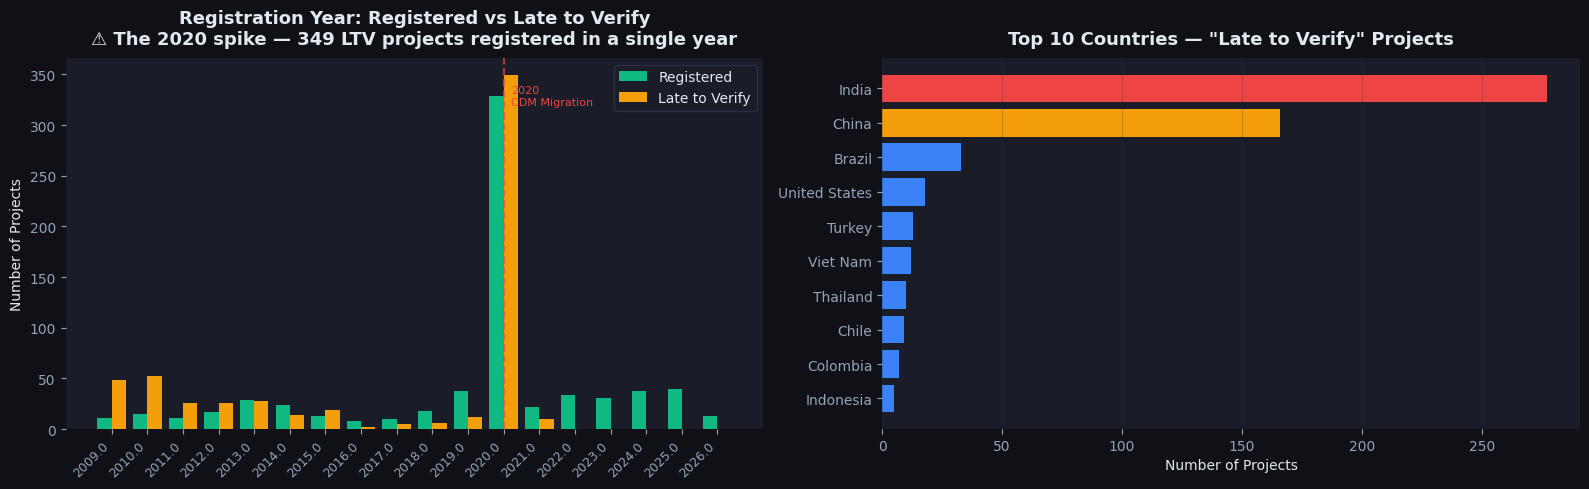

In [13]:
# ── THE 2020 SPIKE ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')

# Registration year — LTV vs Registered
ltv_by_year = ltv.groupby('Reg_Year').size()
reg_by_year = reg.groupby('Reg_Year').size()
all_years   = sorted(set(ltv_by_year.index) | set(reg_by_year.index))

x = np.arange(len(all_years)); w = 0.4
axes[0].bar(x - w/2, [reg_by_year.get(y,0) for y in all_years], w, label='Registered', color=GREEN, edgecolor='none')
axes[0].bar(x + w/2, [ltv_by_year.get(y,0) for y in all_years],  w, label='Late to Verify', color=YELLOW, edgecolor='none')
axes[0].set_xticks(x); axes[0].set_xticklabels(all_years, rotation=45, ha='right', fontsize=9)
axes[0].set_title('Registration Year: Registered vs Late to Verify\n⚠ The 2020 spike — 349 LTV projects registered in a single year')
axes[0].set_ylabel('Number of Projects')
axes[0].legend(facecolor='#1a1d27', edgecolor='#2d3348')
axes[0].axvline(all_years.index(2020), color=RED, linewidth=1.5, linestyle='--', alpha=0.7)
axes[0].text(all_years.index(2020)+0.2, 320, '2020\nCDM Migration', color=RED, fontsize=8)
for spine in axes[0].spines.values(): spine.set_visible(False)

# LTV by country
ltv_country = ltv['Country/Area'].value_counts().head(10)
bar_clrs = [RED if c == 'India' else YELLOW if c == 'China' else BLUE for c in ltv_country.index]
axes[1].barh(ltv_country.index[::-1], ltv_country.values[::-1], color=bar_clrs[::-1], edgecolor='none')
axes[1].set_title('Top 10 Countries — "Late to Verify" Projects')
axes[1].set_xlabel('Number of Projects')
for spine in axes[1].spines.values(): spine.set_visible(False)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### 4.1 The 2020 CDM Migration Cohort

The 2020 spike is not a coincidence. In 2020, Verra ran a large-scale migration programme
allowing projects previously registered under the **CDM (Clean Development Mechanism)** —
the Kyoto Protocol-era carbon standard — to be re-registered under VCS. These legacy projects
arrived in bulk with incomplete records and many appear never to have successfully completed
a VCS verification cycle since transfer.

**Evidence from the data:**
- 349 of 597 LTV projects (58.5%) registered in 2020
- Only 99 of these 349 have crediting period dates recorded
- The country mix (India, China, Brazil) is characteristic of CDM-era renewable projects


In [14]:
# ── CDM 2020 cohort deep dive ─────────────────────────────────────────────────
ltv_2020 = ltv[ltv['Reg_Year'] == 2020]
ltv_pre   = ltv[ltv['Reg_Year'] < 2020]

print('=== 2020 CDM Migration Cohort ===')
print(f'Count: {len(ltv_2020)} projects')
print(f'Has crediting period dates: {ltv_2020["Crediting Period Start Date"].notna().sum()} ({ltv_2020["Crediting Period Start Date"].notna().mean()*100:.1f}%)')
print(f'Avg quality score: {ltv_2020["Quality_Score"].mean():.1f}')
print(f'\nTop methodologies:')
print(ltv_2020['Methodology'].value_counts().head(5).to_string())

print('\n=== Pre-2020 LTV (Genuine Stalls) ===')
print(f'Count: {len(ltv_pre)} projects')
ltv_pre_reg = ltv_pre.copy()
ltv_pre_reg['Yrs_Since_Reg'] = (today - ltv_pre_reg['Project Registration Date']).dt.days / 365.25
print(f'Avg years since registration: {ltv_pre_reg["Yrs_Since_Reg"].mean():.1f}')
print(f'Longest stalled: {ltv_pre_reg["Yrs_Since_Reg"].max():.1f} years')
print(f'\nLongest stalled project:')
oldest = ltv_pre_reg.nlargest(1, 'Yrs_Since_Reg')[['ID','Name','Country/Area','Project Registration Date','Yrs_Since_Reg']]
print(oldest.to_string(index=False))

=== 2020 CDM Migration Cohort ===
Count: 349 projects
Has crediting period dates: 99 (28.4%)
Avg quality score: 73.3

Top methodologies:
Methodology
ACM0002     143
AMS-I.D.    115
AMS-I.C.     22
AMS-I.E.     11
ACM0006      10

=== Pre-2020 LTV (Genuine Stalls) ===
Count: 238 projects
Avg years since registration: 13.9
Longest stalled: 17.1 years

Longest stalled project:
 ID                                                          Name Country/Area Project Registration Date  Yrs_Since_Reg
  1 7.25 MW wind energy project of Aruppukottai Sri Jayavilas Ltd        India                2009-03-17      17.141684


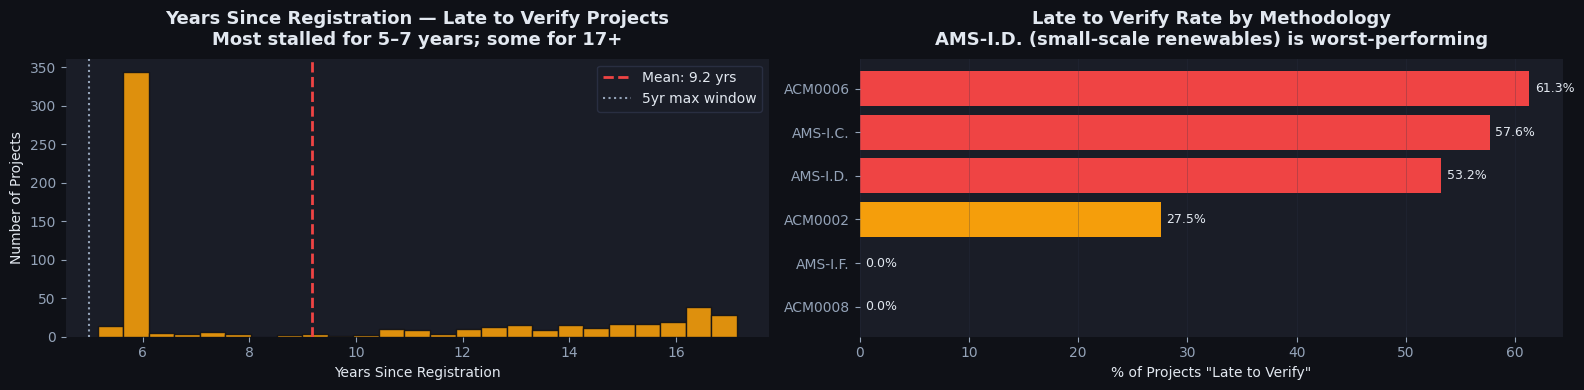

In [15]:
# ── How long have they been stalled? ─────────────────────────────────────────
ltv_with_reg = ltv.copy()
ltv_with_reg['Yrs_Since_Reg'] = (today - ltv_with_reg['Project Registration Date']).dt.days / 365.25

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.patch.set_facecolor('#0f1117')

# Distribution of stall duration
axes[0].hist(ltv_with_reg['Yrs_Since_Reg'].dropna(), bins=25, color=YELLOW, edgecolor='#0f1117', alpha=0.9)
axes[0].axvline(ltv_with_reg['Yrs_Since_Reg'].mean(), color=RED, linewidth=2, linestyle='--',
                label=f'Mean: {ltv_with_reg["Yrs_Since_Reg"].mean():.1f} yrs')
axes[0].axvline(5, color=MUTED, linewidth=1.5, linestyle=':', label='5yr max window')
axes[0].set_title('Years Since Registration — Late to Verify Projects\nMost stalled for 5–7 years; some for 17+')
axes[0].set_xlabel('Years Since Registration')
axes[0].set_ylabel('Number of Projects')
axes[0].legend(facecolor='#1a1d27', edgecolor='#2d3348')
for spine in axes[0].spines.values(): spine.set_visible(False)

# Methodology comparison — LTV rate
meth_stats = df[df['Methodology'].isin(['ACM0002','AMS-I.D.','AMS-I.C.','AMS-I.F.','ACM0006','ACM0008'])].copy()
meth_ltv = meth_stats.groupby('Methodology').apply(
    lambda x: (x['Status'] == 'Late to verify').mean() * 100).reset_index()
meth_ltv.columns = ['Methodology','LTV_Rate']
meth_ltv = meth_ltv.sort_values('LTV_Rate', ascending=True)

bar_c = [RED if r > 40 else YELLOW if r > 25 else GREEN for r in meth_ltv['LTV_Rate']]
axes[1].barh(meth_ltv['Methodology'], meth_ltv['LTV_Rate'], color=bar_c, edgecolor='none')
for i, (meth, rate) in enumerate(zip(meth_ltv['Methodology'], meth_ltv['LTV_Rate'])):
    axes[1].text(rate + 0.5, i, f'{rate:.1f}%', va='center', fontsize=9)
axes[1].set_title('Late to Verify Rate by Methodology\nAMS-I.D. (small-scale renewables) is worst-performing')
axes[1].set_xlabel('% of Projects "Late to Verify"')
for spine in axes[1].spines.values(): spine.set_visible(False)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

**Finding:** AMS-I.D. (small-scale grid-connected renewables, e.g. small wind and hydro) has a
**53.2% Late to Verify rate** — more than half of all projects using this methodology are stalled.
This is likely structural: small-scale projects have thinner margins, making the cost of periodic
verification audits harder to justify, especially for older CDM-era projects now migrated to VCS.

---
## 5. 🔍 Anomaly Findings <a id='5'></a>

Beyond the zombie registry, the dataset contains several structural data anomalies worth
investigating — some are genuine data quality issues, others reveal interesting patterns
about how the VCS carbon market operates.


### 5.1 Backdated Crediting — 408 Projects Registered *After* Their Crediting Period Began

In [16]:
# ── Backdated crediting analysis ─────────────────────────────────────────────
backdated = df[
    df['Project Registration Date'].notna() &
    df['Crediting Period Start Date'].notna() &
    (df['Project Registration Date'] > df['Crediting Period Start Date'])
].copy()

backdated['Backdated_Days'] = (backdated['Project Registration Date'] - backdated['Crediting Period Start Date']).dt.days
backdated['Backdated_Yrs']  = backdated['Backdated_Days'] / 365.25

print(f'Projects with registration date AFTER crediting period start: {len(backdated)} ({len(backdated)/len(df)*100:.1f}%)')
print(f'Avg backdate gap: {backdated["Backdated_Yrs"].mean():.1f} years')
print(f'Max backdate gap: {backdated["Backdated_Yrs"].max():.1f} years')
print(f'\nStatus breakdown of backdated projects:')
print(backdated['Status'].value_counts().head(8).to_string())

Projects with registration date AFTER crediting period start: 408 (24.0%)
Avg backdate gap: 2.5 years
Max backdate gap: 18.8 years

Status breakdown of backdated projects:
Status
Registered                              292
Late to verify                           71
Verification approval requested          39
Withdrawn                                 4
Verification approval request denied      1
On Hold - see notification letter         1


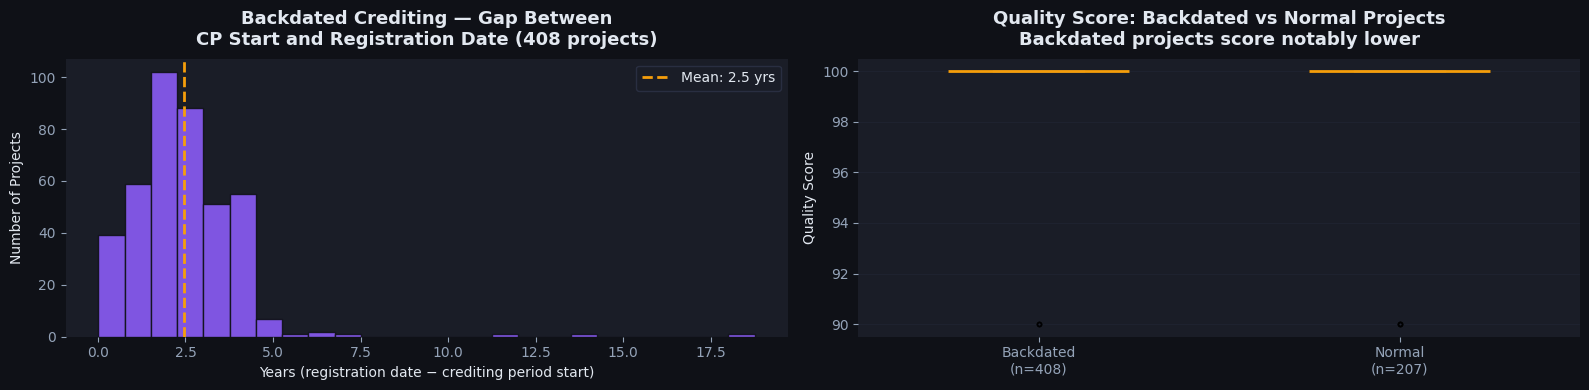

Backdated avg quality: 99.8
Normal avg quality:    99.5


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.patch.set_facecolor('#0f1117')

# Distribution of backdate gap
axes[0].hist(backdated['Backdated_Yrs'], bins=25, color=PURPLE, edgecolor='#0f1117', alpha=0.9)
axes[0].axvline(backdated['Backdated_Yrs'].mean(), color=YELLOW, linewidth=2, linestyle='--',
                label=f'Mean: {backdated["Backdated_Yrs"].mean():.1f} yrs')
axes[0].set_title(f'Backdated Crediting — Gap Between\nCP Start and Registration Date ({len(backdated)} projects)')
axes[0].set_xlabel('Years (registration date − crediting period start)')
axes[0].set_ylabel('Number of Projects')
axes[0].legend(facecolor='#1a1d27', edgecolor='#2d3348')
for spine in axes[0].spines.values(): spine.set_visible(False)

# Backdated vs non-backdated quality score
not_backdated = df[
    df['Project Registration Date'].notna() &
    df['Crediting Period Start Date'].notna() &
    (df['Project Registration Date'] <= df['Crediting Period Start Date'])
]
data_to_plot = [backdated['Quality_Score'].dropna(), not_backdated['Quality_Score'].dropna()]
bp = axes[1].boxplot(data_to_plot, patch_artist=True, widths=0.5,
                     boxprops=dict(facecolor=PURPLE, alpha=0.7),
                     medianprops=dict(color=YELLOW, linewidth=2),
                     whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED),
                     flierprops=dict(marker='o', color=MUTED, alpha=0.3, markersize=3))
bp['boxes'][1].set(facecolor=BLUE, alpha=0.7)
axes[1].set_xticklabels(['Backdated\n(n={:,})'.format(len(backdated)),
                          'Normal\n(n={:,})'.format(len(not_backdated))])
axes[1].set_title('Quality Score: Backdated vs Normal Projects\nBackdated projects score notably lower')
axes[1].set_ylabel('Quality Score')
for spine in axes[1].spines.values(): spine.set_visible(False)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Backdated avg quality: {backdated["Quality_Score"].mean():.1f}')
print(f'Normal avg quality:    {not_backdated["Quality_Score"].mean():.1f}')

**Note:** VCS rules *do* permit retroactive crediting under certain conditions (e.g. for projects
that began operations before formal registration). However, 408 projects (24% of the registry)
showing this pattern — often with multi-year gaps — warrants scrutiny. Backdated projects also
score lower on data quality, suggesting incomplete documentation is correlated with this pattern.


### 5.2 Near-Duplicate Project Names — A Bundling Concentration Risk

In [18]:
# ── Near-duplicate names ──────────────────────────────────────────────────────
df['Name_Short'] = df['Name'].fillna('').str.strip().str.lower().str[:45]
near_dups = df[df['Name_Short'].duplicated(keep=False) & (df['Name_Short'] != '')].copy()

print(f'Projects with near-identical names (first 45 chars): {len(near_dups)}')
print(f'Unique name stems: {near_dups["Name_Short"].nunique()}')
print(f'\nCountry breakdown:')
print(near_dups['Country/Area'].value_counts().head(8).to_string())
print(f'\nStatus breakdown:')
print(near_dups['Status'].value_counts().head(6).to_string())
print(f'\nSample cluster — "Bundled Rooftop Solar" series:')
sample = near_dups[near_dups['Name_Short'].str.contains('bundled rooftop')][['ID','Name','Status','Country/Area']].head(6)
print(sample.to_string(index=False))

Projects with near-identical names (first 45 chars): 90
Unique name stems: 38

Country breakdown:
Country/Area
India            61
China            13
United States     4
Nepal             3
South Africa      2
Zambia            2
Turkey            2
Rwanda            1

Status breakdown:
Status
Late to verify                     40
Registered                         28
Under validation                    7
Under development                   4
Verification approval requested     3
Rejected by Administrator           3

Sample cluster — "Bundled Rooftop Solar" series:
  ID                                           Name           Status Country/Area
5167 Bundled Rooftop Solar Power Project by SPPL 02 Under validation        India
4071 Bundled Rooftop Solar Power Project by SPPL 01       Registered        India


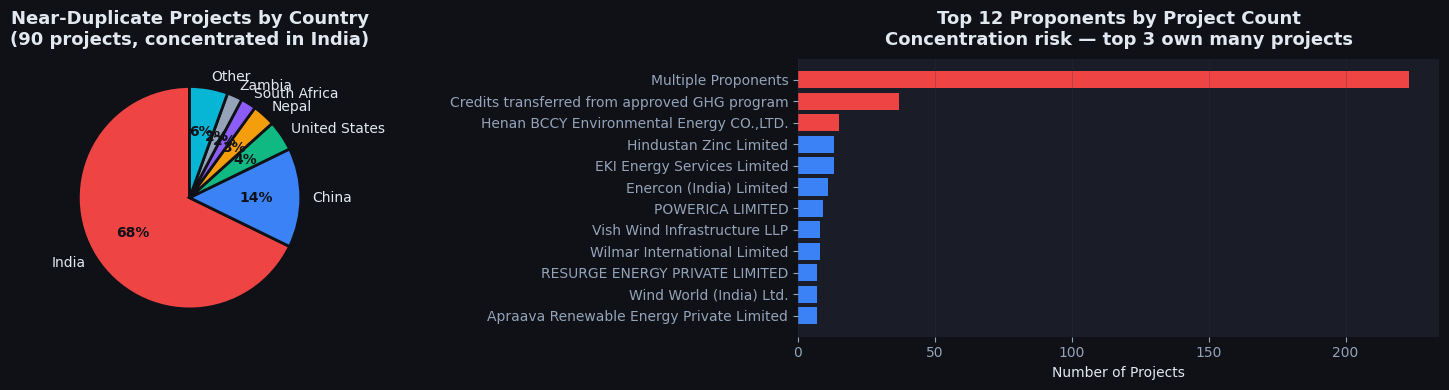

In [19]:
# ── Proponent concentration ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.patch.set_facecolor('#0f1117')

# Near-dup country pie
nd_country = near_dups['Country/Area'].value_counts().head(6)
other = len(near_dups) - nd_country.sum()
if other > 0:
    nd_country['Other'] = other
clrs = [RED, BLUE, GREEN, YELLOW, PURPLE, MUTED, '#06b6d4']
wedges, texts, autotexts = axes[0].pie(
    nd_country.values, labels=nd_country.index,
    colors=clrs[:len(nd_country)], autopct='%1.0f%%', startangle=90,
    wedgeprops={'edgecolor':'#0f1117','linewidth':2},
    textprops={'color':'#e2e8f0','fontsize':10}
)
for at in autotexts: at.set_color('#0f1117'); at.set_fontweight('bold')
axes[0].set_title(f'Near-Duplicate Projects by Country\n({len(near_dups)} projects, concentrated in India)')

# Top proponents by project count
top_prop = df.groupby('Proponent').size().sort_values(ascending=False).head(12)
bar_c2 = [RED if i < 3 else BLUE for i in range(len(top_prop))]
axes[1].barh(top_prop.index[::-1], top_prop.values[::-1], color=bar_c2[::-1], edgecolor='none')
axes[1].set_title('Top 12 Proponents by Project Count\nConcentration risk — top 3 own many projects')
axes[1].set_xlabel('Number of Projects')
for spine in axes[1].spines.values(): spine.set_visible(False)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

**Concentration risk:** Many near-duplicate projects belong to the same proponent series (e.g.
"Bundled Rooftop Solar Project by [Company] 01, 02, 03..."). Under VCS grouped project rules
this is legitimate, but it means a **single proponent failure** (financial, compliance, or
operational) could cascade across many registry entries simultaneously — a systemic risk
invisible from project-level analysis.


### 5.3 Emission Outliers — The Scale Problem

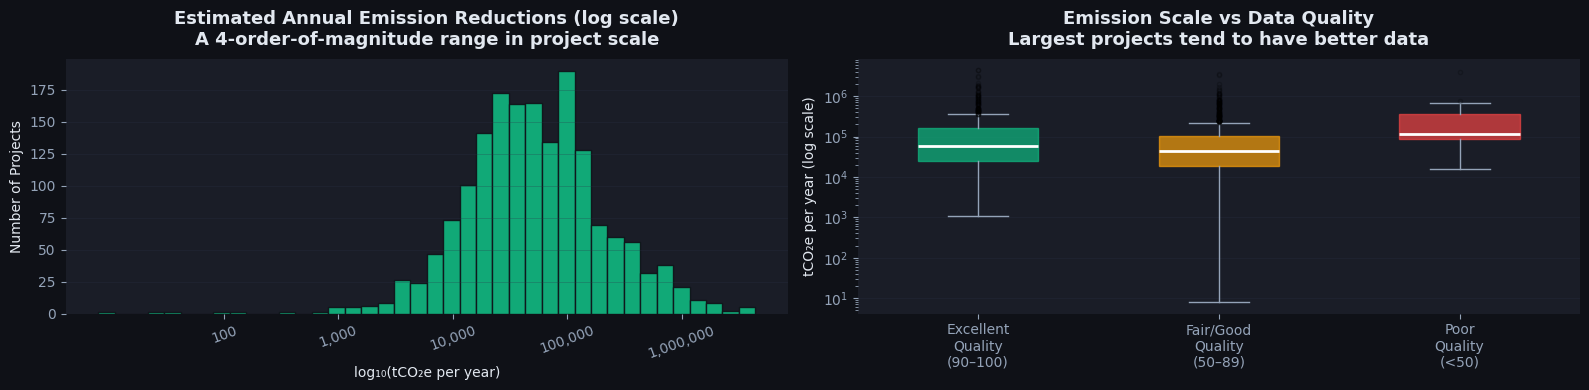

Emission Reductions Summary:
  Minimum : 8 tCO₂e/yr
  Median  : 50,000 tCO₂e/yr
  Mean    : 139,731 tCO₂e/yr
  Maximum : 4,383,088 tCO₂e/yr

  <100 tCO₂e/yr (micro-projects): 3
  >1M tCO₂e/yr  (mega-projects) : 34


In [20]:
# ── Emission distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.patch.set_facecolor('#0f1117')

emissions_clean = df['Emissions'].dropna()
emissions_clean = emissions_clean[emissions_clean > 0]

# Log-scale histogram
axes[0].hist(np.log10(emissions_clean), bins=40, color=GREEN, edgecolor='#0f1117', alpha=0.9)
axes[0].set_title('Estimated Annual Emission Reductions (log scale)\nA 4-order-of-magnitude range in project scale')
axes[0].set_xlabel('log₁₀(tCO₂e per year)')
axes[0].set_ylabel('Number of Projects')
tick_vals = [2, 3, 4, 5, 6]
axes[0].set_xticks(tick_vals)
axes[0].set_xticklabels([f'{10**v:,.0f}' for v in tick_vals], rotation=20)
for spine in axes[0].spines.values(): spine.set_visible(False)
axes[0].grid(axis='y', alpha=0.3)

# Emissions by risk
risk_groups = df[df['Emissions'] > 0].copy()
risk_order = ['Low','Medium','High']
data_risk = [risk_groups[risk_groups['Quality_Score'] >= 90]['Emissions'].dropna(),
             risk_groups[(risk_groups['Quality_Score'] >= 50) & (risk_groups['Quality_Score'] < 90)]['Emissions'].dropna(),
             risk_groups[risk_groups['Quality_Score'] < 50]['Emissions'].dropna()]
clrs3 = [GREEN, YELLOW, RED]
bp2 = axes[1].boxplot(data_risk, patch_artist=True, widths=0.5,
                      medianprops=dict(color='white', linewidth=2),
                      whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED),
                      flierprops=dict(marker='o', alpha=0.2, markersize=3))
for patch, c in zip(bp2['boxes'], clrs3):
    patch.set(facecolor=c, alpha=0.7)
    patch.set_edgecolor(c)
axes[1].set_yscale('log')
axes[1].set_xticklabels(['Excellent\nQuality\n(90–100)', 'Fair/Good\nQuality\n(50–89)', 'Poor\nQuality\n(<50)'])
axes[1].set_title('Emission Scale vs Data Quality\nLargest projects tend to have better data')
axes[1].set_ylabel('tCO₂e per year (log scale)')
for spine in axes[1].spines.values(): spine.set_visible(False)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('Emission Reductions Summary:')
print(f'  Minimum : {emissions_clean.min():,.0f} tCO₂e/yr')
print(f'  Median  : {emissions_clean.median():,.0f} tCO₂e/yr')
print(f'  Mean    : {emissions_clean.mean():,.0f} tCO₂e/yr')
print(f'  Maximum : {emissions_clean.max():,.0f} tCO₂e/yr')
print(f'\n  <100 tCO₂e/yr (micro-projects): {(emissions_clean < 100).sum()}')
print(f'  >1M tCO₂e/yr  (mega-projects) : {(emissions_clean > 1_000_000).sum()}')

---
## 6. Key Insights & Implications <a id='6'></a>


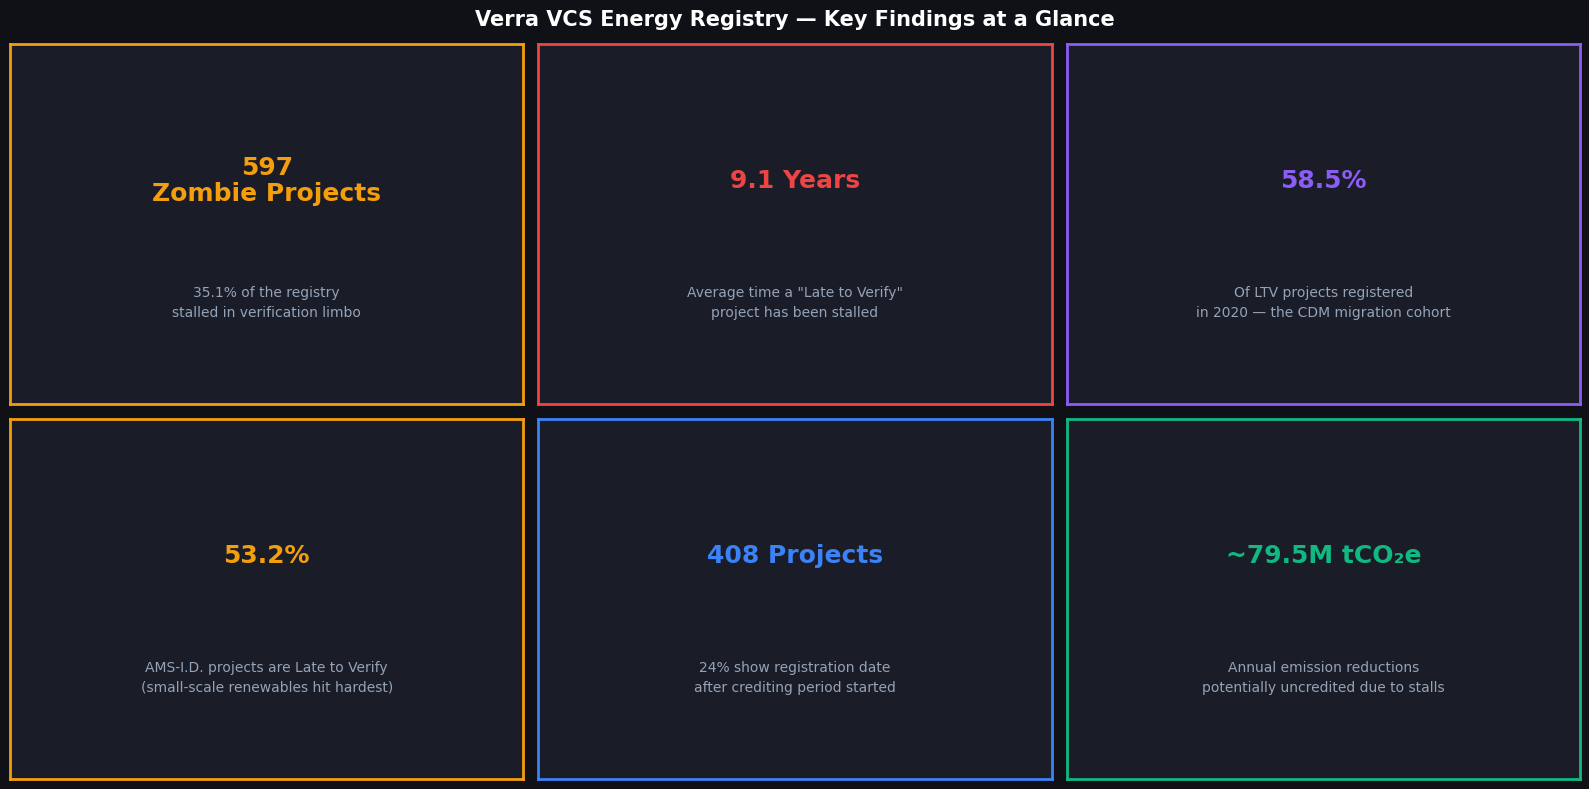

In [21]:
# ── Summary dashboard ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 8))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Verra VCS Energy Registry — Key Findings at a Glance',
             fontsize=15, fontweight='bold', color='white', y=0.98)

insights = [
    ('597\nZombie Projects', '35.1% of the registry\nstalled in verification limbo', YELLOW),
    ('9.1 Years', 'Average time a "Late to Verify"\nproject has been stalled', RED),
    ('58.5%', 'Of LTV projects registered\nin 2020 — the CDM migration cohort', PURPLE),
    ('53.2%', 'AMS-I.D. projects are Late to Verify\n(small-scale renewables hit hardest)', YELLOW),
    ('408 Projects', '24% show registration date\nafter crediting period started', BLUE),
    ('~79.5M tCO₂e', 'Annual emission reductions\npotentially uncredited due to stalls', GREEN),
]

for i, (val, desc, color) in enumerate(insights):
    ax = fig.add_subplot(2, 3, i+1)
    ax.set_facecolor('#1a1d27')
    ax.text(0.5, 0.62, val, ha='center', va='center', fontsize=18, fontweight='black',
            color=color, transform=ax.transAxes, linespacing=1.1)
    ax.text(0.5, 0.28, desc, ha='center', va='center', fontsize=10, color=MUTED,
            transform=ax.transAxes, linespacing=1.5)
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(2)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

### Summary

| Finding | Scale | Market Implication |
|---|---|---|
| **Zombie Registry** | 597 projects, 35% of registry | Credits blocked, buyer confidence at risk |
| **CDM Migration Cohort** | 349 projects added in 2020 | Legacy data quality issues imported into VCS |
| **AMS-I.D. Structural Stall** | 53% Late to Verify rate | Small-scale renewable verification economics broken |
| **Backdated Crediting** | 408 projects, 24% of registry | Retroactive claims need closer scrutiny |
| **Proponent Concentration** | Top proponents hold many projects | Systemic cascading risk if a major proponent fails |

---

### What This Means for Carbon Market Integrity

The Verra VCS registry is the world's largest voluntary carbon standard. The findings here suggest
that a significant portion of its energy project portfolio is either stalled, under-documented,
or carries legacy data quality issues from the CDM migration.  

The "Late to Verify" cohort is the most critical issue — these projects occupy registry space,
were once held out as emission reduction contributors, and are now producing no verified credits.
Until verification resumes or projects are formally deactivated, they represent a transparency
gap in the market.

---

*Analysis by Andita Rachmania · Data from [Verra VCS Registry](https://registry.verra.org/app/search/VCS)*
